# 05 — Model Training

Entrenamiento de **GBR** (HistGradientBoostingRegressor) y **CatBoost** para estimar turbidez superficial.
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import json

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr

from catboost import CatBoostRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
RANDOM_STATE = 42

/home/adriancr/.pyenv/versions/deep-sat/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configuración

In [25]:
BASE_DIR = Path('..')
FE_DIR   = BASE_DIR / 'data' / 'processed' / 'feature_engineering'
RES_DIR  = BASE_DIR / 'results'
MOD_DIR  = RES_DIR / 'models'
for d in [RES_DIR, MOD_DIR]:
    d.mkdir(exist_ok=True)

# 5 datasets de parches circulares
DATASET_CONFIG = {
    'patch_16px':  {'file': 'fe_16px_stats.parquet',  'radius_px': 8,   'diameter_m': 48},
    'patch_32px':  {'file': 'fe_32px_stats.parquet',  'radius_px': 16,  'diameter_m': 96},
    'patch_64px':  {'file': 'fe_64px_stats.parquet',  'radius_px': 32,  'diameter_m': 192},
    'patch_128px': {'file': 'fe_128px_stats.parquet', 'radius_px': 64,  'diameter_m': 384},
    'patch_256px': {'file': 'fe_256px_stats.parquet', 'radius_px': 128, 'diameter_m': 768},
}

META_COLS       = ['ctd', 'date', 'turbidity', 'n_pixels']
TEST_FRAC       = 0.20   # 20% de fechas mas recientes → test
N_CV_SPLITS     = 5
EARLY_STOP      = 50
N_MAX_ITERS     = 800
N_OPTUNA_TRIALS = 30

print(f'Datasets: {list(DATASET_CONFIG.keys())}')

Datasets: ['patch_16px', 'patch_32px', 'patch_64px', 'patch_128px', 'patch_256px']


## 2. Preprocessor y funciones utilitarias

**Preprocessor**: aplica `log1p` a las 40 estadísticas de banda (mean/median/std/p10/p90 × 8 bandas).  
Los 5 índices espectrales (ndti, red_green, …) se dejan sin transformar.

**Por qué log1p**: las DN de uint16 tienen valores extremos en datos nublados/turbios de train  
(max≈10000) que no aparecen en test (max≈1800), causando un ratio de std de 3.2×.  
Después de log1p el ratio baja a ~0.93× → distribuciones equivalentes.

In [3]:
class Preprocessor:
    """log1p en estadisticas de banda; indices espectrales intactos."""

    def __init__(self, feat_cols):
        stat_suf = ('_mean', '_median', '_std', '_p10', '_p90')
        self.log_idx   = [i for i, c in enumerate(feat_cols)
                           if any(c.endswith(s) for s in stat_suf)]
        self.feat_cols = list(feat_cols)

    def _apply(self, X):
        X = X.copy()
        X[:, self.log_idx] = np.log1p(np.maximum(X[:, self.log_idx], 0.0))
        return X

    def fit_transform(self, X):
        return self._apply(X)

    def transform(self, X):
        return self._apply(X)


print('Preprocessor definido.')

Preprocessor definido.


In [4]:
def load_dataset(ds_name):
    cfg  = DATASET_CONFIG[ds_name]
    df   = pd.read_parquet(FE_DIR / cfg['file'])
    df['date'] = pd.to_datetime(df['date'])
    df   = df.dropna(subset=['turbidity']).reset_index(drop=True)
    feat = [c for c in df.columns if c not in META_COLS]
    return df, feat


def temporal_split(df):
    """80/20 split temporal sin leakage."""
    dates  = sorted(df['date'].unique())
    n_test = max(1, int(len(dates) * TEST_FRAC))
    tr_d   = dates[:-n_test]
    te_d   = dates[-n_test:]
    return (df[df['date'].isin(tr_d)].reset_index(drop=True),
            df[df['date'].isin(te_d)].reset_index(drop=True),
            tr_d, te_d)


def compute_metrics(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0.0)
    return dict(
        mae       = round(mean_absolute_error(y_true, y_pred), 4),
        rmse      = round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        r2        = round(r2_score(y_true, y_pred), 4),
        pearson_r = round(pearsonr(y_true, y_pred)[0], 4),
        bias      = round(float(np.mean(y_pred - y_true)), 4),
    )


def predict_orig(model, X_proc):
    """Prediccion en escala original (expm1 + clip 0)."""
    return np.maximum(np.expm1(model.predict(X_proc)), 0.0)


print('Funciones utilitarias cargadas.')

Funciones utilitarias cargadas.


## 3. Diagnóstico de distribución train vs test

Verifica el efecto de `log1p` sobre la alineación de distribuciones.

Ratio std train/test (DN bruto):  3.79x  (>1 = shift de distribucion)
Ratio std train/test (log1p):     0.85x  (objetivo ~1.0)
Turbidez — Train: media=1.47 NTU  Test: media=0.91 NTU


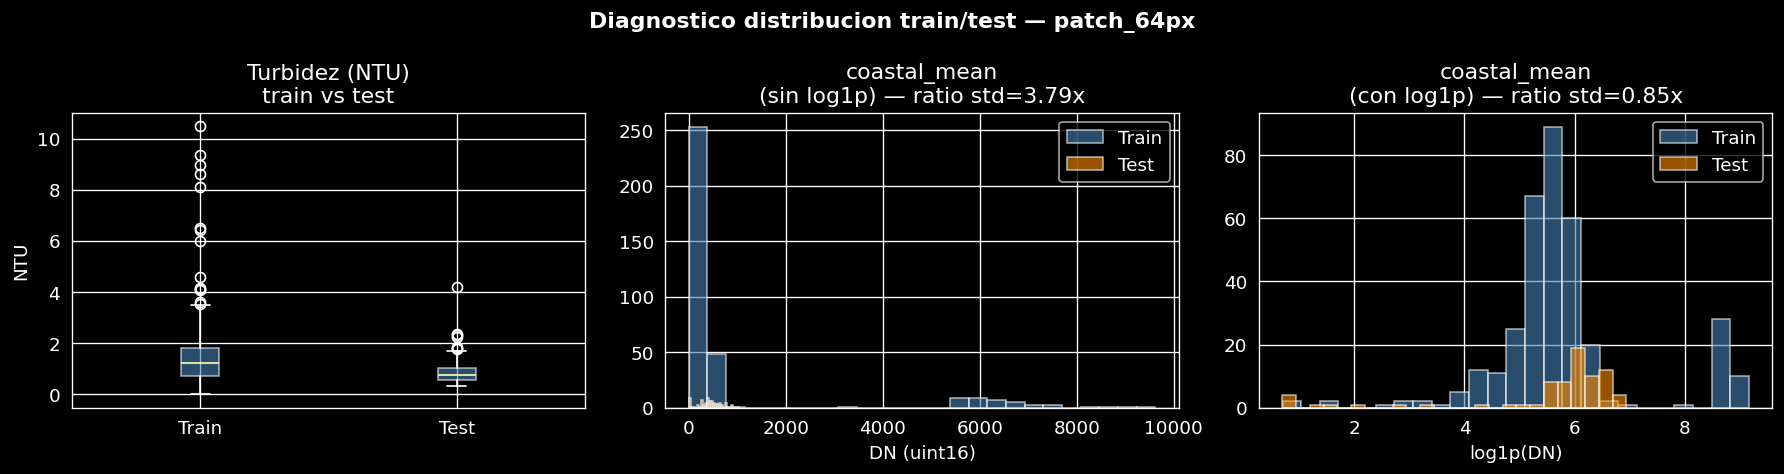

In [5]:
ref_ds = 'patch_64px'
df_ref, feat_ref = load_dataset(ref_ds)
tr_ref, te_ref, _, _ = temporal_split(df_ref)

X_tr_raw = tr_ref[feat_ref].values.astype(np.float64)
X_te_raw = te_ref[feat_ref].values.astype(np.float64)
prep_ref  = Preprocessor(feat_ref)
X_tr_proc = prep_ref.fit_transform(X_tr_raw)
X_te_proc = prep_ref.transform(X_te_raw)

stat_suf = ('_mean', '_median', '_std', '_p10', '_p90')
log_idx  = [i for i, c in enumerate(feat_ref) if any(c.endswith(s) for s in stat_suf)]

def _mean_std_ratio(Xtr, Xte, idx_list):
    ratios = []
    for i in idx_list:
        s_te = np.nanstd(Xte[:, i])
        if s_te > 0:
            ratios.append(np.nanstd(Xtr[:, i]) / s_te)
    return float(np.mean(ratios)) if ratios else np.nan

ratio_raw  = _mean_std_ratio(X_tr_raw,  X_te_raw,  log_idx)
ratio_proc = _mean_std_ratio(X_tr_proc, X_te_proc, log_idx)

print(f'Ratio std train/test (DN bruto):  {ratio_raw:.2f}x  (>1 = shift de distribucion)')
print(f'Ratio std train/test (log1p):     {ratio_proc:.2f}x  (objetivo ~1.0)')
print(f'Turbidez — Train: media={tr_ref["turbidity"].mean():.2f} NTU  '
      f'Test: media={te_ref["turbidity"].mean():.2f} NTU')

# ── Plots ────────────────────────────────────────────────────────────────────
ci = feat_ref.index('coastal_mean') if 'coastal_mean' in feat_ref else log_idx[0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.boxplot([tr_ref['turbidity'].values, te_ref['turbidity'].values],
           labels=['Train', 'Test'], patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.set_title('Turbidez (NTU)\ntrain vs test')
ax.set_ylabel('NTU')

ax = axes[1]
ax.hist(X_tr_raw[:, ci], bins=25, alpha=0.6, label='Train', color='steelblue')
ax.hist(X_te_raw[:, ci], bins=25, alpha=0.6, label='Test',  color='darkorange')
ax.set_title(f'{feat_ref[ci]}\n(sin log1p) — ratio std={ratio_raw:.2f}x')
ax.set_xlabel('DN (uint16)')
ax.legend()

ax = axes[2]
ax.hist(X_tr_proc[:, ci], bins=25, alpha=0.6, label='Train', color='steelblue')
ax.hist(X_te_proc[:, ci], bins=25, alpha=0.6, label='Test',  color='darkorange')
ax.set_title(f'{feat_ref[ci]}\n(con log1p) — ratio std={ratio_proc:.2f}x')
ax.set_xlabel('log1p(DN)')
ax.legend()

plt.suptitle(f'Diagnostico distribucion train/test — {ref_ds}', fontweight='bold')
plt.tight_layout()
plt.savefig(RES_DIR / 'training_distribution_check.png', bbox_inches='tight')
plt.show()

## 4. Búsqueda de hiperparámetros con Optuna

Bayesian search (TPE) con `GroupKFold` dentro del objetivo → sin leakage temporal.

In [6]:
def _gbr_objective(trial, X_tr, y_tr_l, groups):
    params = dict(
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.30, log=True),
        max_leaf_nodes    = trial.suggest_int('max_leaf_nodes', 15, 127),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 40),
        l2_regularization = trial.suggest_float('l2_regularization', 1e-6, 10.0, log=True),
        max_features      = trial.suggest_float('max_features', 0.5, 1.0),
    )
    kf = GroupKFold(n_splits=N_CV_SPLITS)
    scores = []
    for tr_idx, val_idx in kf.split(X_tr, y_tr_l, groups):
        m = HistGradientBoostingRegressor(
            max_iter=N_MAX_ITERS,
            n_iter_no_change=EARLY_STOP,
            validation_fraction=0.12,
            random_state=RANDOM_STATE,
            **params
        )
        m.fit(X_tr[tr_idx], y_tr_l[tr_idx])
        pred_orig = np.maximum(np.expm1(m.predict(X_tr[val_idx])), 0.0)
        y_orig    = np.expm1(y_tr_l[val_idx])
        scores.append(mean_absolute_error(y_orig, pred_orig))
    return float(np.mean(scores))


def _cat_objective(trial, X_tr, y_tr_l, groups):
    params = dict(
        depth               = trial.suggest_int('depth', 4, 10),
        learning_rate       = trial.suggest_float('learning_rate', 0.01, 0.30, log=True),
        l2_leaf_reg         = trial.suggest_float('l2_leaf_reg', 1.0, 20.0),
        min_data_in_leaf    = trial.suggest_int('min_data_in_leaf', 1, 20),
        bagging_temperature = trial.suggest_float('bagging_temperature', 0.0, 2.0),
    )
    kf = GroupKFold(n_splits=N_CV_SPLITS)
    scores = []
    for tr_idx, val_idx in kf.split(X_tr, y_tr_l, groups):
        m = CatBoostRegressor(
            iterations=N_MAX_ITERS,
            loss_function='MAE',
            eval_metric='MAE',
            bootstrap_type='Bayesian',
            random_seed=RANDOM_STATE,
            thread_count=-1,
            verbose=False,
            **params
        )
        m.fit(X_tr[tr_idx], y_tr_l[tr_idx],
              eval_set=(X_tr[val_idx], y_tr_l[val_idx]),
              early_stopping_rounds=EARLY_STOP,
              verbose=False)
        pred_orig = np.maximum(np.expm1(m.predict(X_tr[val_idx])), 0.0)
        y_orig    = np.expm1(y_tr_l[val_idx])
        scores.append(mean_absolute_error(y_orig, pred_orig))
    return float(np.mean(scores))


def run_optuna(model_type, X_tr, y_tr_l, groups, n_trials=N_OPTUNA_TRIALS):
    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    if model_type == 'GBR':
        obj = lambda t: _gbr_objective(t, X_tr, y_tr_l, groups)
    else:
        obj = lambda t: _cat_objective(t, X_tr, y_tr_l, groups)

    study.optimize(obj, n_trials=n_trials, show_progress_bar=False)
    best_p = dict(study.best_params)
    print(f'    Optuna({n_trials} trials): CV_MAE={study.best_value:.4f}')
    return best_p


print('Funciones Optuna cargadas.')

Funciones Optuna cargadas.


## 5. CV con early stopping y entrenamiento final

In [7]:
def cv_early_stopping(model_type, X_tr, y_tr_l, groups, best_params,
                       n_splits=N_CV_SPLITS, early_stop=EARLY_STOP):
    """
    GroupKFold CV con early stopping.
    Devuelve predicciones OOF (log-escala), metricas por fold y n_iters por fold.
    """
    if model_type not in ('GBR', 'CatBoost'):
        raise ValueError(f'model_type desconocido: {model_type}')

    kf      = GroupKFold(n_splits=n_splits)
    oof_log = np.full(len(y_tr_l), np.nan)
    fold_met = []
    best_its = []

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_tr, y_tr_l, groups)):
        Xtr, Xval = X_tr[tr_idx], X_tr[val_idx]
        ytr, yval = y_tr_l[tr_idx], y_tr_l[val_idx]

        if model_type == 'GBR':
            m = HistGradientBoostingRegressor(
                max_iter=N_MAX_ITERS,
                n_iter_no_change=early_stop,
                validation_fraction=0.12,
                random_state=RANDOM_STATE,
                **best_params
            )
            m.fit(Xtr, ytr)
            bi       = m.n_iter_
            pred_log = m.predict(Xval)
        else:  # CatBoost
            m = CatBoostRegressor(
                iterations=N_MAX_ITERS,
                loss_function='MAE',
                eval_metric='MAE',
                bootstrap_type='Bayesian',
                random_seed=RANDOM_STATE,
                thread_count=-1,
                verbose=False,
                **best_params
            )
            m.fit(Xtr, ytr,
                  eval_set=(Xval, yval),
                  early_stopping_rounds=early_stop,
                  verbose=False)
            bi       = m.get_best_iteration()
            pred_log = m.predict(Xval)

        oof_log[val_idx] = pred_log
        best_its.append(bi)

        pred_orig = np.maximum(np.expm1(pred_log), 0.0)
        y_orig    = np.expm1(yval)
        fold_met.append(compute_metrics(y_orig, pred_orig))

    return oof_log, fold_met, best_its


def train_final(model_type, X_tr, y_tr_l, best_its, best_params):
    """Modelo final sobre TODO el training set usando n_iters = media(CV best_its) + 1."""
    n_iters = max(int(np.round(np.mean(best_its))) + 1, 10)

    if model_type == 'GBR':
        m = HistGradientBoostingRegressor(
            max_iter=n_iters,
            random_state=RANDOM_STATE,
            **best_params
        )
        m.fit(X_tr, y_tr_l)
    else:  # CatBoost
        m = CatBoostRegressor(
            iterations=n_iters,
            loss_function='MAE',
            eval_metric='MAE',
            bootstrap_type='Bayesian',
            random_seed=RANDOM_STATE,
            thread_count=-1,
            verbose=False,
            **best_params
        )
        m.fit(X_tr, y_tr_l, verbose=False)

    return m, n_iters


print('Funciones de CV y entrenamiento final cargadas.')

Funciones de CV y entrenamiento final cargadas.


## 6. Loop de entrenamiento: GBR + CatBoost × 5 datasets

In [8]:
models_to_train = ['GBR', 'CatBoost']

all_results  = []
oof_records  = []
test_records = []

print(f'Entrenando {len(DATASET_CONFIG)} datasets x {len(models_to_train)} modelos '
      f'= {len(DATASET_CONFIG)*len(models_to_train)} combinaciones\n')

for ds_name, ds_cfg in DATASET_CONFIG.items():
    df, feat_cols = load_dataset(ds_name)
    tr_df, te_df, tr_d, te_d = temporal_split(df)

    X_tr_raw = tr_df[feat_cols].values.astype(np.float64)
    X_te_raw = te_df[feat_cols].values.astype(np.float64)
    y_tr     = tr_df['turbidity'].values
    y_te     = te_df['turbidity'].values
    y_tr_l   = np.log1p(y_tr)
    groups   = pd.Categorical(tr_df['date']).codes

    # Preprocessor: log1p en estadisticas de banda
    preprocessor = Preprocessor(feat_cols)
    X_tr = preprocessor.fit_transform(X_tr_raw)
    X_te = preprocessor.transform(X_te_raw)

    # Guardar preprocessor y feat_cols (una vez por dataset)
    pickle.dump(preprocessor, open(MOD_DIR / f'{ds_name}__preprocessor.pkl', 'wb'))
    pickle.dump(feat_cols,    open(MOD_DIR / f'{ds_name}__feat_cols.pkl',    'wb'))

    for mtype in models_to_train:
        print(f'[{ds_name}] {mtype}')

        # 1. Optuna: busqueda de hiperparametros
        print(f'  Buscando hiperparametros ({N_OPTUNA_TRIALS} trials)...', flush=True)
        best_params = run_optuna(mtype, X_tr, y_tr_l, groups)

        # 2. CV con early stopping: OOF + best_iters
        print(f'  CV (k={N_CV_SPLITS})...', flush=True)
        oof_log, fold_met, best_its = cv_early_stopping(
            mtype, X_tr, y_tr_l, groups, best_params)

        cv_mae     = float(np.mean([m['mae']  for m in fold_met]))
        cv_mae_std = float(np.std( [m['mae']  for m in fold_met]))
        cv_rmse    = float(np.mean([m['rmse'] for m in fold_met]))
        cv_r2      = float(np.mean([m['r2']   for m in fold_met]))

        # 3. Modelo final sobre todo el training set
        final_model, n_iters = train_final(mtype, X_tr, y_tr_l, best_its, best_params)

        # 4. Metricas
        tr_pred  = predict_orig(final_model, X_tr)
        tr_met   = compute_metrics(y_tr, tr_pred)
        te_pred  = predict_orig(final_model, X_te)
        te_met   = compute_metrics(y_te, te_pred)
        oof_orig = np.maximum(np.expm1(oof_log), 0.0)
        oof_met  = compute_metrics(y_tr, oof_orig)

        print(f'  n_iters={n_iters:4d} | '
              f'Train MAE={tr_met["mae"]:.3f} R2={tr_met["r2"]:.3f} | '
              f'OOF MAE={oof_met["mae"]:.3f} | '
              f'CV {cv_mae:.3f}+-{cv_mae_std:.3f} | '
              f'Test MAE={te_met["mae"]:.3f} R2={te_met["r2"]:.3f}')

        # 5. Guardar modelo
        model_key = f'{ds_name}__{mtype}'
        pickle.dump(final_model, open(MOD_DIR / f'{model_key}.pkl', 'wb'))

        # 6. Registrar metricas
        all_results.append({
            'dataset': ds_name, 'diameter_m': ds_cfg['diameter_m'],
            'model': mtype, 'n_train': len(tr_df), 'n_test': len(te_df),
            'n_iters': n_iters,
            **{f'train_{k}': v for k, v in tr_met.items()},
            **{f'test_{k}':  v for k, v in te_met.items()},
            **{f'oof_{k}':   v for k, v in oof_met.items()},
            'cv_mae':     round(cv_mae, 4),
            'cv_mae_std': round(cv_mae_std, 4),
            'cv_rmse':    round(cv_rmse, 4),
            'cv_r2':      round(cv_r2, 4),
            'best_iter_mean': round(np.mean(best_its), 1),
            'best_iter_std':  round(np.std(best_its), 1),
        })

        # 7. Registrar predicciones test
        for row_df, pred_val in zip(te_df.itertuples(), te_pred):
            test_records.append({
                'ctd': row_df.ctd, 'date': row_df.date,
                'turbidity': row_df.turbidity, 'pred': pred_val,
                'dataset': ds_name, 'model': mtype,
            })

        # 8. Registrar predicciones OOF
        for row_df, oof_val in zip(tr_df.itertuples(), oof_orig):
            oof_records.append({
                'ctd': row_df.ctd, 'date': row_df.date,
                'turbidity': row_df.turbidity, 'pred': oof_val,
                'dataset': ds_name, 'model': mtype,
            })

print('\nEntrenamiento finalizado.')

Entrenando 5 datasets x 2 modelos = 10 combinaciones

[patch_16px] GBR
  Buscando hiperparametros (30 trials)...
    Optuna(30 trials): CV_MAE=0.8638
  CV (k=5)...
  n_iters= 801 | Train MAE=0.011 R2=0.999 | OOF MAE=0.859 | CV 0.864+-0.389 | Test MAE=0.694 R2=-1.849
[patch_16px] CatBoost
  Buscando hiperparametros (30 trials)...
    Optuna(30 trials): CV_MAE=0.7633
  CV (k=5)...
  n_iters=  31 | Train MAE=0.430 R2=0.414 | OOF MAE=0.759 | CV 0.763+-0.409 | Test MAE=0.579 R2=-0.618
[patch_32px] GBR
  Buscando hiperparametros (30 trials)...
    Optuna(30 trials): CV_MAE=0.8535
  CV (k=5)...
  n_iters= 801 | Train MAE=0.008 R2=0.999 | OOF MAE=0.849 | CV 0.854+-0.388 | Test MAE=0.779 R2=-1.955
[patch_32px] CatBoost
  Buscando hiperparametros (30 trials)...
    Optuna(30 trials): CV_MAE=0.7653
  CV (k=5)...
  n_iters= 125 | Train MAE=0.327 R2=0.548 | OOF MAE=0.761 | CV 0.765+-0.413 | Test MAE=0.572 R2=-0.498
[patch_64px] GBR
  Buscando hiperparametros (30 trials)...
    Optuna(30 trials): CV

## 7. Tabla de resultados: Train vs OOF vs CV vs Test

In [9]:
metrics_df = pd.DataFrame(all_results)

metrics_df.to_csv(RES_DIR / 'model_metrics.csv', index=False)
pd.DataFrame(test_records).to_csv(RES_DIR / 'test_predictions.csv', index=False)
pd.DataFrame(oof_records).to_csv(RES_DIR  / 'oof_predictions.csv',  index=False)

cols_show = ['dataset', 'model',
             'train_mae', 'train_r2',
             'oof_mae',
             'cv_mae', 'cv_mae_std',
             'test_mae', 'test_rmse', 'test_r2',
             'n_iters']
display(
    metrics_df[cols_show]
    .sort_values('test_mae')
    .reset_index(drop=True)
    .rename(columns={
        'train_mae': 'Train MAE', 'train_r2': 'Train R2',
        'oof_mae':   'OOF MAE',
        'cv_mae':    'CV MAE',    'cv_mae_std': 'CV std',
        'test_mae':  'Test MAE',  'test_rmse': 'Test RMSE', 'test_r2': 'Test R2',
    })
)

,dataset,model,Train MAE,Train R2,OOF MAE,CV MAE,CV std,Test MAE,Test RMSE,Test R2,n_iters
0,patch_64px,CatBoost,0.3233,0.5240,0.7671,0.7713,0.4109,0.5371,0.6646,-0.2447,216
1,patch_128px,CatBoost,0.5365,0.2096,0.7672,0.7713,0.4131,0.5429,0.6586,-0.2226,64
2,patch_128px,GBR,0.0102,0.9988,0.8237,0.8283,0.4008,0.5676,0.7536,-0.6007,801
3,patch_32px,CatBoost,0.3266,0.5481,0.7609,0.7653,0.4129,0.5721,0.7292,-0.4985,125
4,patch_16px,CatBoost,0.4304,0.4145,0.7590,0.7633,0.4089,0.5786,0.7578,-0.6183,31
5,patch_256px,CatBoost,0.6363,0.1172,0.7795,0.7837,0.4276,0.5818,0.6812,-0.3079,16
6,patch_64px,GBR,0.1228,0.9520,0.8586,0.8631,0.3876,0.6302,0.8485,-1.0292,801
7,patch_256px,GBR,0.3589,0.7306,0.8882,0.8932,0.3968,0.6652,0.8684,-1.1251,801
8,patch_16px,GBR,0.0114,0.9989,0.8589,0.8638,0.3886,0.6943,1.0054,-1.8489,801
9,patch_32px,GBR,0.0078,0.9993,0.8489,0.8535,0.3878,0.7793,1.0239,-1.9546,801


## 8. Visualización rápida

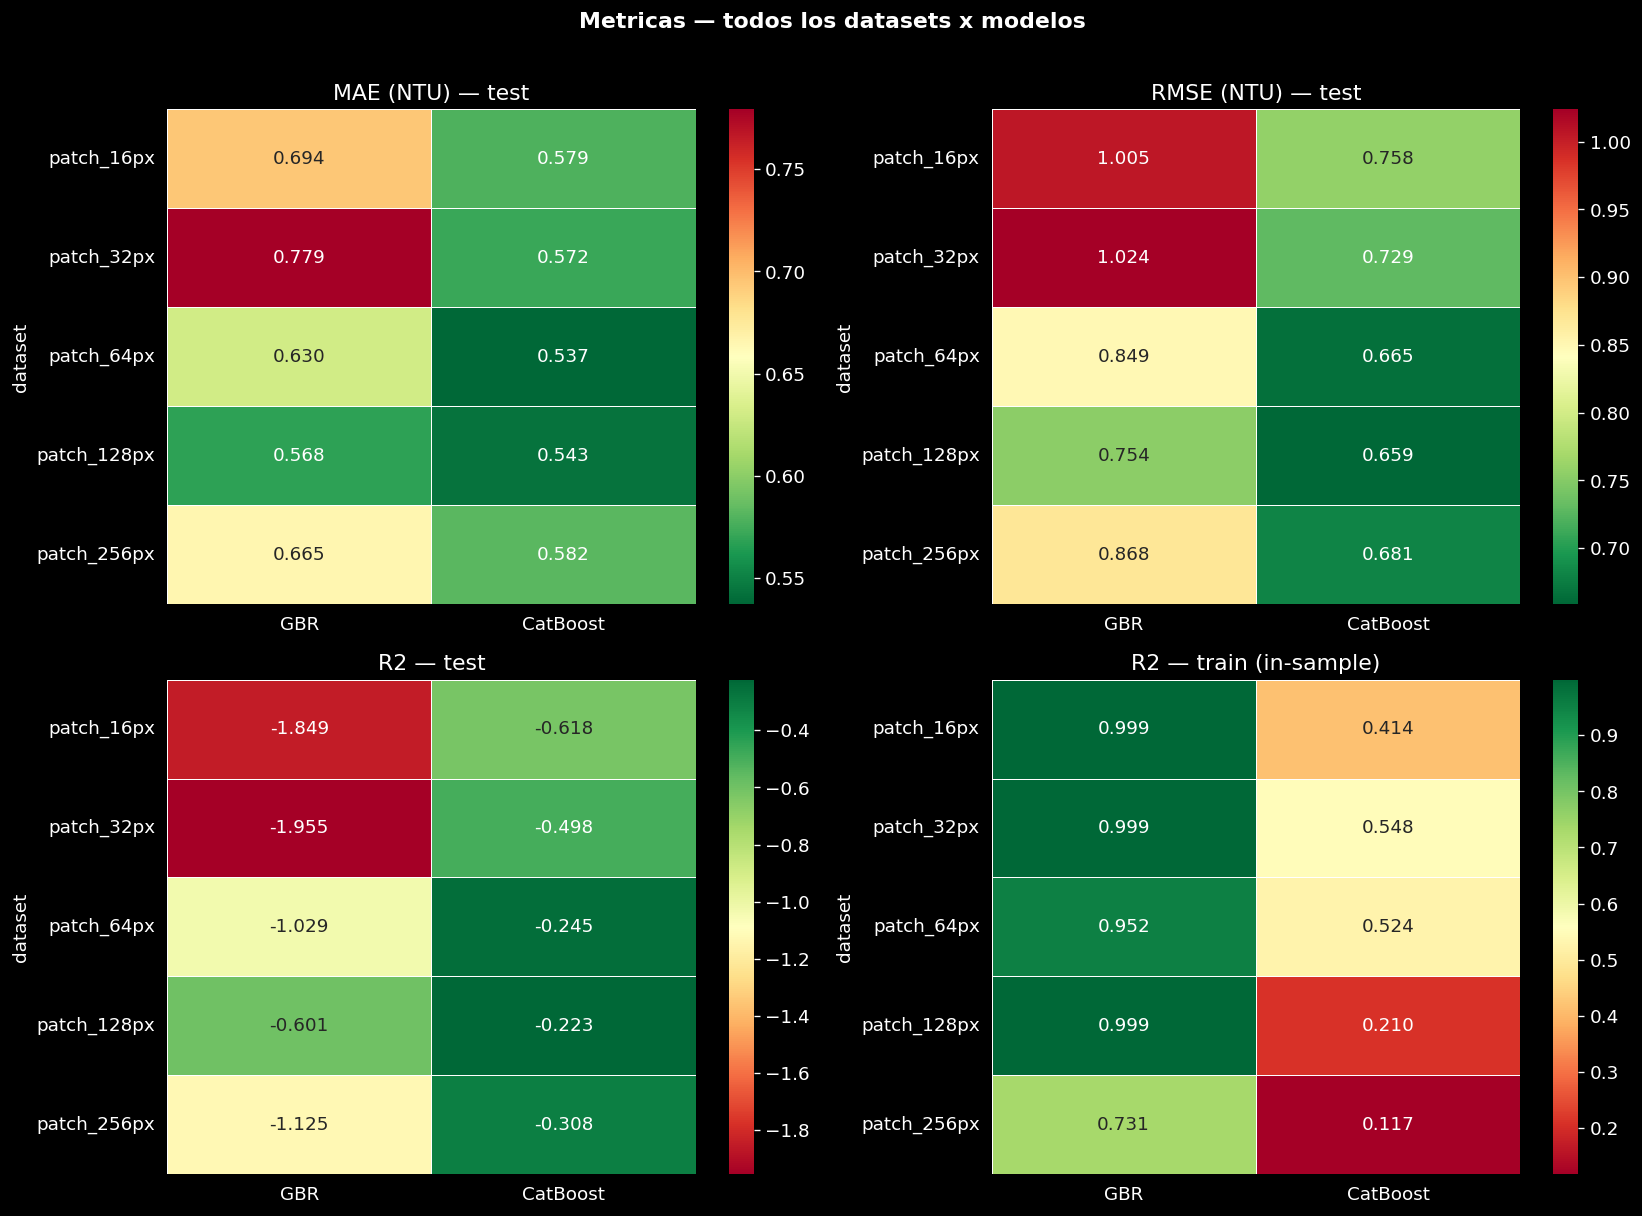

In [10]:
available_models = metrics_df['model'].unique().tolist()
DS_ORDER = list(DATASET_CONFIG.keys())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (metric, label, cmap, fmt) in zip(axes.flatten(), [
    ('test_mae',  'MAE (NTU) — test',  'RdYlGn_r', '.3f'),
    ('test_rmse', 'RMSE (NTU) — test', 'RdYlGn_r', '.3f'),
    ('test_r2',   'R2 — test',         'RdYlGn',   '.3f'),
    ('train_r2',  'R2 — train (in-sample)', 'RdYlGn', '.3f'),
]):
    pivot = (metrics_df.pivot(index='dataset', columns='model', values=metric)
             .reindex(index=[d for d in DS_ORDER if d in metrics_df['dataset'].values],
                      columns=available_models))
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap,
                ax=ax, linewidths=0.5, annot_kws={'size': 11})
    ax.set_title(label)
    ax.set_xlabel('')

plt.suptitle('Metricas — todos los datasets x modelos', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(RES_DIR / 'training_heatmap.png', bbox_inches='tight')
plt.show()

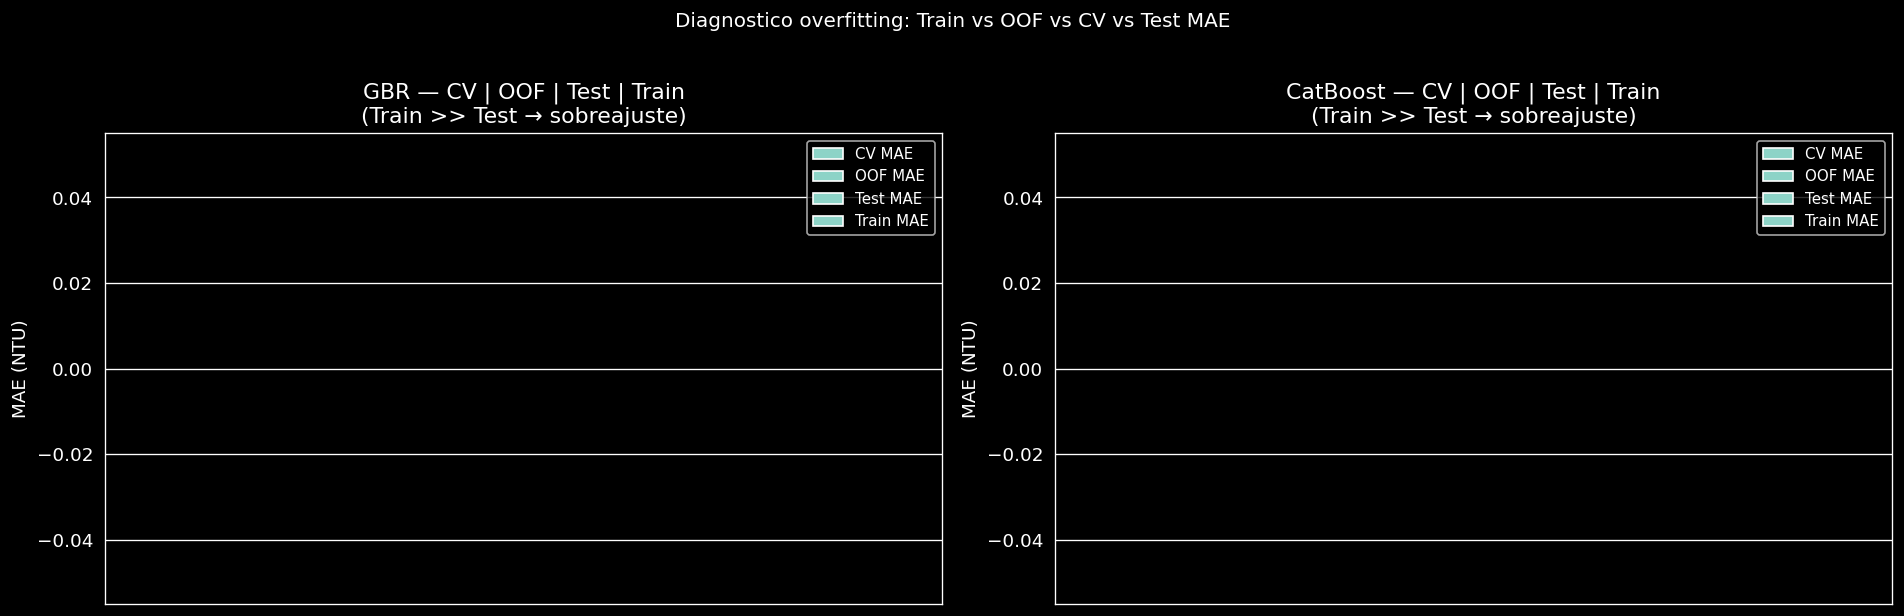

In [11]:
fig, axes = plt.subplots(1, len(available_models), figsize=(8 * len(available_models), 5))
if len(available_models) == 1:
    axes = [axes]

MODEL_COLORS = {'GBR': '#2196F3', 'CatBoost': '#4472C4'}

for ax, mtype in zip(axes, available_models):
    sub = metrics_df[metrics_df['model'] == mtype].copy()
    sub = sub.set_index('dataset').reindex([d for d in DS_ORDER if d in sub.index])
    x   = np.arange(len(sub))
    w   = 0.22

    ax.bar(x - 1.5*w, sub['cv_mae'],   width=w, label='CV MAE',   color='#5B9BD5', alpha=0.85)
    ax.bar(x - 0.5*w, sub['oof_mae'],  width=w, label='OOF MAE',  color='#ED7D31', alpha=0.85)
    ax.bar(x + 0.5*w, sub['test_mae'], width=w, label='Test MAE', color='#70AD47', alpha=0.85)
    ax.bar(x + 1.5*w, sub['train_mae'],width=w, label='Train MAE',color='#FFC000', alpha=0.85)

    ax.errorbar(x - 1.5*w, sub['cv_mae'], yerr=sub['cv_mae_std'],
                fmt='none', color='black', capsize=4, linewidth=1.2, zorder=5)

    ax.set_xticks(x)
    ax.set_xticklabels(sub.index, rotation=25, ha='right')
    ax.set_ylabel('MAE (NTU)')
    ax.set_title(f'{mtype} — CV | OOF | Test | Train\n(Train >> Test → sobreajuste)')
    ax.legend(fontsize=9)

plt.suptitle('Diagnostico overfitting: Train vs OOF vs CV vs Test MAE',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(RES_DIR / 'training_overfitting_check.png', bbox_inches='tight')
plt.show()

## 9. Mejor combinación y archivos para notebooks 06 y 07

In [12]:
best_row = metrics_df.loc[metrics_df['test_mae'].idxmin()]
best_ds  = best_row['dataset']
best_mod = best_row['model']

print(f'Mejor combinacion: dataset={best_ds}  modelo={best_mod}')
print(f'  Train MAE={best_row["train_mae"]:.4f}  R2={best_row["train_r2"]:.4f}')
print(f'  OOF   MAE={best_row["oof_mae"]:.4f}')
print(f'  CV    MAE={best_row["cv_mae"]:.4f} +- {best_row["cv_mae_std"]:.4f}')
print(f'  Test  MAE={best_row["test_mae"]:.4f}  RMSE={best_row["test_rmse"]:.4f}  '
      f'R2={best_row["test_r2"]:.4f}')

best_cfg = {
    'best_dataset':      best_ds,
    'best_model':        best_mod,
    'radius_px':         int(DATASET_CONFIG[best_ds]['radius_px']),
    'diameter_m':        int(DATASET_CONFIG[best_ds]['diameter_m']),
    'model_file':        f'{best_ds}__{best_mod}.pkl',
    'feat_cols_file':    f'{best_ds}__feat_cols.pkl',
    'preprocessor_file': f'{best_ds}__preprocessor.pkl',
    'map_dataset':       best_ds,
    'map_radius_px':     int(DATASET_CONFIG[best_ds]['radius_px']),
}
with open(RES_DIR / 'best_model_info.json', 'w') as f:
    json.dump(best_cfg, f, indent=2)
with open(RES_DIR / 'dataset_config.json', 'w') as f:
    json.dump(DATASET_CONFIG, f, indent=2)

print('\nArchivos guardados en results/:')
print('  model_metrics.csv, test_predictions.csv, oof_predictions.csv')
print('  best_model_info.json, dataset_config.json')
print(f'  models/{best_ds}__{best_mod}.pkl  (+ {len(DATASET_CONFIG)*len(models_to_train)-1} mas)')
print(f'  models/{best_ds}__preprocessor.pkl  (necesario en notebook 07)')

Mejor combinacion: dataset=patch_64px  modelo=CatBoost
  Train MAE=0.3233  R2=0.5240
  OOF   MAE=0.7671
  CV    MAE=0.7713 +- 0.4109
  Test  MAE=0.5371  RMSE=0.6646  R2=-0.2447

Archivos guardados en results/:
  model_metrics.csv, test_predictions.csv, oof_predictions.csv
  best_model_info.json, dataset_config.json
  models/patch_64px__CatBoost.pkl  (+ 9 mas)
  models/patch_64px__preprocessor.pkl  (necesario en notebook 07)
